# Deep Learning Foundations — Ejemplos Prácticos
**Prof. Ing. Carlos Andrés Sierra, M.Sc. — Universidad Distrital FJC**

Este notebook complementa las diapositivas del módulo *Deep Learning: Foundations*.
Solo contiene los ejercicios correspondientes a los slides marcados con **⚗️ Practical Example**.

| Sección | Slide | Ejemplo |
|---------|-------|---------|
| 1 | Deep Learning Foundations | Gradientes en redes profundas vs superficiales |
| 2 | Convolutional Neural Networks | CNN en MNIST — de la línea base al ResNet |
| 3 | Sequence Models & Transformers | Clasificación de sentimiento: LSTM vs Transformer |
| 4 | Unsupervised & Representation Learning | Detección de anomalías con AutoEncoder |

In [1]:
import sys, subprocess

# Instala los paquetes necesarios en el kernel activo.
# numpy<2 requerido porque torch 2.2.2 fue compilado con numpy 1.x.
_pkgs = [
    'torch', 'torchvision',
    'numpy<2', 'matplotlib', 'scikit-learn',
]
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--prefer-binary'] + _pkgs
)
print('Paquetes instalados correctamente.')

Paquetes instalados correctamente.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


---
## Sección 1 — Gradientes en Redes Profundas vs Superficiales
**Slide:** *Practical Example: Training Deep vs Shallow Networks*

Visualizamos cómo la norma del gradiente cambia capa a capa según:
- La función de activación (sigmoide vs ReLU)
- La inicialización de pesos (aleatoria vs He)
- La profundidad de la red (3, 8, 15 capas)

> **Experimenta:** cambia `init='he'` por `init='random'` o `activation='relu'` por `activation='sigmoid'`
> y observa cómo se modifica el comportamiento del gradiente.

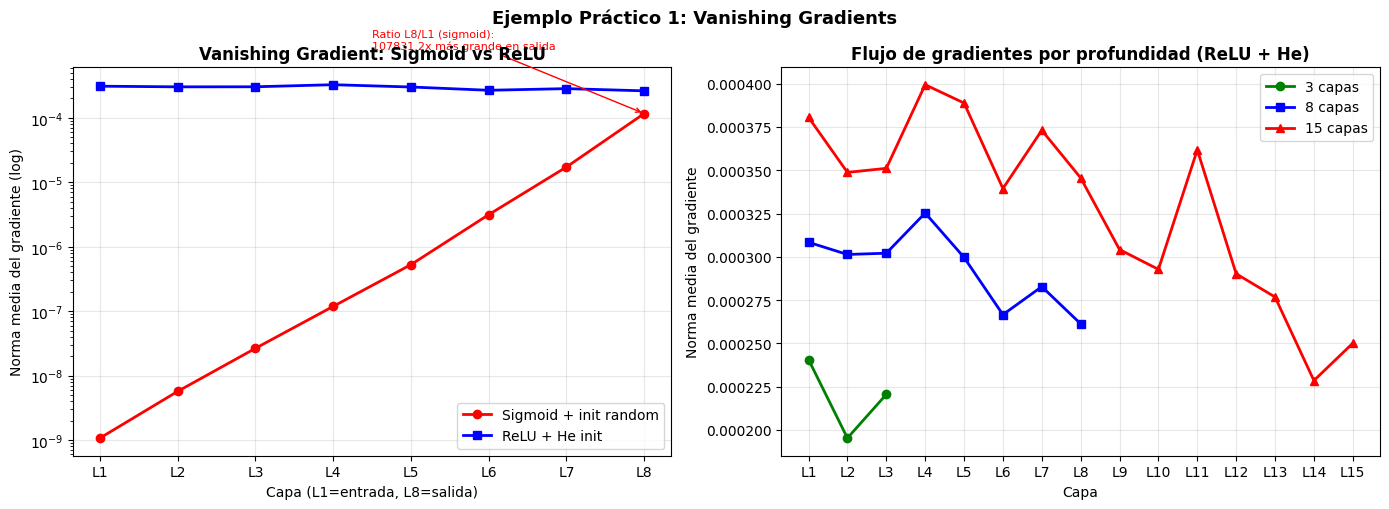


=== Resumen ===
Sigmoid — L1 (entrada): 1.08e-09  |  L8 (salida): 1.16e-04
  ↳ El gradiente en L1 es 107831.2x el de L8  → capas iniciales aprenden muy poco
ReLU+He — L1: 3.08e-04  |  L8: 2.61e-04
  ↳ Ratio L8/L1 = 0.85  → gradiente estable


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Funciones de activación ───────────────────────────────────────────────────
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1 - s)  # máximo 0.25 → satura y aplana el gradiente

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)  # 1 para x>0, 0 para x≤0 → no satura

# ── Simulación del flujo de gradiente ────────────────────────────────────────
def gradient_norms_per_layer(n_layers=8, n_neurons=64,
                              activation='relu', init='he'):
    """
    Simula backpropagation en una red densa y retorna
    la norma media del gradiente en cada capa (de salida a entrada).
    """
    np.random.seed(42)

    # Inicialización de pesos
    weights = []
    for _ in range(n_layers):
        if init == 'xavier':
            scale = np.sqrt(2.0 / (n_neurons * 2))
        elif init == 'he':
            scale = np.sqrt(2.0 / n_neurons)      # correcto para ReLU
        else:                                       # 'random' — escala pequeña
            scale = 0.1
        weights.append(np.random.randn(n_neurons, n_neurons) * scale)

    act_fn   = sigmoid      if activation == 'sigmoid' else relu
    act_grad = sigmoid_grad if activation == 'sigmoid' else relu_grad

    # Forward pass
    x = np.random.randn(32, n_neurons)  # batch de 32
    activations, pre_acts = [x], []
    for W in weights:
        z = activations[-1] @ W
        pre_acts.append(z)
        activations.append(act_fn(z))

    # Backward pass — gradiente desde la salida
    grad  = np.ones_like(activations[-1]) / activations[-1].size
    norms = []
    for l in range(n_layers - 1, -1, -1):
        grad = grad * act_grad(pre_acts[l])
        norms.append(float(np.mean(np.abs(grad))))
        grad = grad @ weights[l].T
    norms.reverse()   # orden: capa 1 (más cercana a la entrada) ... capa L
    return norms


# ── Gráfica 1: Sigmoid vs ReLU+He (8 capas) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

norms_sig  = gradient_norms_per_layer(8, activation='sigmoid', init='random')
norms_relu = gradient_norms_per_layer(8, activation='relu',    init='he')
layers_8   = [f'L{i+1}' for i in range(8)]

axes[0].plot(layers_8, norms_sig,  'r-o', linewidth=2, label='Sigmoid + init random')
axes[0].plot(layers_8, norms_relu, 'b-s', linewidth=2, label='ReLU + He init')
axes[0].set_yscale('log')
axes[0].set_title('Vanishing Gradient: Sigmoid vs ReLU', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Capa (L1=entrada, L8=salida)')
axes[0].set_ylabel('Norma media del gradiente (log)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Anotación de ratio
ratio = norms_sig[-1] / max(norms_sig[0], 1e-15)
axes[0].annotate(
    f'Ratio L8/L1 (sigmoid):\n{ratio:.1f}x más grande en salida',
    xy=(7, norms_sig[-1]), xytext=(3.5, norms_sig[-1] * 10),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=8, color='red'
)

# ── Gráfica 2: Efecto de la profundidad con ReLU+He ───────────────────────────
for n, color, marker in [(3, 'green', 'o'), (8, 'blue', 's'), (15, 'red', '^')]:
    norms = gradient_norms_per_layer(n, activation='relu', init='he')
    axes[1].plot([f'L{i+1}' for i in range(n)], norms,
                 f'-{marker}', linewidth=2, label=f'{n} capas', color=color)

axes[1].set_title('Flujo de gradientes por profundidad (ReLU + He)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Capa')
axes[1].set_ylabel('Norma media del gradiente')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Ejemplo Práctico 1: Vanishing Gradients', y=1.01,
             fontsize=13, fontweight='bold')
plt.show()

# ── Resumen numérico ──────────────────────────────────────────────────────────
print('\n=== Resumen ===' )
print(f'Sigmoid — L1 (entrada): {norms_sig[0]:.2e}  |  L8 (salida): {norms_sig[-1]:.2e}')
print(f'  ↳ El gradiente en L1 es {norms_sig[-1]/max(norms_sig[0],1e-15):.1f}x'
      f' el de L8  → capas iniciales aprenden muy poco')
print(f'ReLU+He — L1: {norms_relu[0]:.2e}  |  L8: {norms_relu[-1]:.2e}')
print(f'  ↳ Ratio L8/L1 = {norms_relu[-1]/max(norms_relu[0],1e-15):.2f}  → gradiente estable')

---
## Sección 2 — CNN en MNIST: de la Línea Base al ResNet
**Slide:** *Practical Example: Training Deep vs Shallow Networks (CNN Edition)*

Comparamos cuatro arquitecturas entrenadas sobre un subconjunto de MNIST (5 000 imágenes):

| Modelo | Descripción |
|--------|-------------|
| **MLP Baseline** | Red densa — sin capacidades convolucionales |
| **Simple CNN** | 2 capas Conv + MaxPool |
| **CNN + BN + Dropout** | Añade BatchNorm y regularización |
| **ResCNN** | CNN con bloques residuales (skip connections) |

> **Experimenta:** quita el BatchNorm del modelo CNN+BN y sube lr a 0.01.
> ¿Se vuelve inestable el entrenamiento?

100%|██████████| 9912422/9912422 [00:06<00:00, 1523777.89it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 350034.37it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 2336645.57it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 4458349.82it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Train: 5000 imágenes  |  Test: 1000 imágenes
Tamaño de imagen: 28×28 (1 canal)  |  Clases: 10 dígitos (0-9)


Entrenando: MLP Baseline
  [MLP Baseline]  parámetros: 235,146   acc final: 0.933

Entrenando: Simple CNN
  [Simple CNN]  parámetros: 206,922   acc final: 0.969

Entrenando: CNN + BN + Dropout
  [CNN + BN + Dropout]  parámetros: 207,018   acc final: 0.973

Entrenando: ResCNN (skip)
  [ResCNN (skip)]  parámetros: 53,322   acc final: 0.978


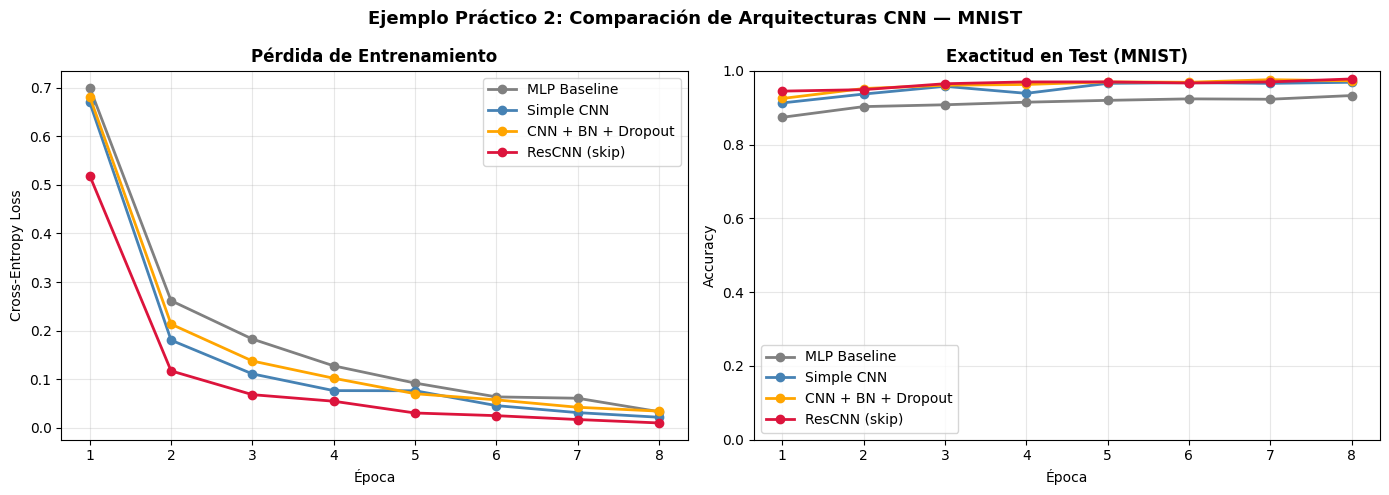


Modelo                     Acc Final
MLP Baseline                   0.933
Simple CNN                     0.969
CNN + BN + Dropout             0.973
ResCNN (skip)                  0.978


In [1]:
import ssl
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ── Dataset — subconjunto de MNIST ────────────────────────────────────────────
# Fix SSL certificate issue on macOS (pyenv Python lacks system certs)
ssl._create_default_https_context = ssl._create_unverified_context
torchvision.datasets.MNIST.mirrors = ["https://ossci-datasets.s3.amazonaws.com/mnist/"]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_full = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_full  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

train_data = Subset(train_full, range(5000))
test_data  = Subset(test_full,  range(1000))

train_loader = DataLoader(train_data, batch_size=64,  shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=256)

print(f'Train: {len(train_data)} imágenes  |  Test: {len(test_data)} imágenes')
print(f'Tamaño de imagen: 28×28 (1 canal)  |  Clases: 10 dígitos (0-9)\n')

# ── Modelo A: MLP Baseline ────────────────────────────────────────────────────
class MLPBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

# ── Modelo B: CNN Simple ───────────────────────────────────────────────────────
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14×14
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 7×7
        )
        self.clf = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 7 * 7, 128), nn.ReLU(), nn.Linear(128, 10)
        )
    def forward(self, x): return self.clf(self.features(x))

# ── Modelo C: CNN + BatchNorm + Dropout ───────────────────────────────────────
class CNNWithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.clf = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 10)
        )
    def forward(self, x): return self.clf(self.features(x))

# ── Modelo D: ResCNN — bloque residual estilo ResNet ──────────────────────────
class ResBlock(nn.Module):
    """Un bloque residual: y = ReLU(F(x) + x), donde F = Conv-BN-ReLU-Conv-BN."""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels), nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.block(x) + x)  # ← la suma residual

class ResCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem  = nn.Sequential(nn.Conv2d(1, 32, 3, padding=1),
                                   nn.BatchNorm2d(32), nn.ReLU())
        self.res1  = ResBlock(32)
        self.pool1 = nn.MaxPool2d(2)                      # 14×14
        self.res2  = ResBlock(32)
        self.pool2 = nn.MaxPool2d(2)                      # 7×7
        self.clf   = nn.Sequential(nn.Flatten(), nn.Linear(32 * 7 * 7, 10))
    def forward(self, x):
        x = self.stem(x)
        x = self.pool1(self.res1(x))
        x = self.pool2(self.res2(x))
        return self.clf(x)

# ── Bucle de entrenamiento ─────────────────────────────────────────────────────
def train_model(model, name, epochs=8, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history   = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                correct += (model(x).argmax(1) == y).sum().item()

        history['loss'].append(total_loss / len(train_loader))
        history['acc'].append(correct / len(test_data))

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  [{name}]  parámetros: {n_params:,}  '
          f' acc final: {history["acc"][-1]:.3f}')
    return history


EPOCHS = 8
models = {
    'MLP Baseline':      MLPBaseline(),
    'Simple CNN':        SimpleCNN(),
    'CNN + BN + Dropout': CNNWithBN(),
    'ResCNN (skip)':     ResCNN(),
}

results = {}
for name, model in models.items():
    print(f'\nEntrenando: {name}')
    results[name] = train_model(model, name, epochs=EPOCHS)

# ── Gráficas comparativas ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['gray', 'steelblue', 'orange', 'crimson']
epochs_range = range(1, EPOCHS + 1)

for (name, hist), color in zip(results.items(), colors):
    axes[0].plot(epochs_range, hist['loss'], '-o', color=color, label=name, linewidth=2)
    axes[1].plot(epochs_range, hist['acc'],  '-o', color=color, label=name, linewidth=2)

axes[0].set_title('Pérdida de Entrenamiento',  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Exactitud en Test (MNIST)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Ejemplo Práctico 2: Comparación de Arquitecturas CNN — MNIST',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '='*55)
print(f'{"Modelo":<25} {"Acc Final":>10}')
print('='*55)
for name, hist in results.items():
    print(f'{name:<25} {hist["acc"][-1]:>10.3f}')
print('='*55)

---
## Sección 3 — Clasificación de Sentimiento: LSTM vs Transformer
**Slide:** *Practical Example: Sentiment Classification with Transformer*

Entrenamos desde cero dos clasificadores de sentimiento (positivo / negativo)
sobre un dataset de reseñas de películas en inglés.

| Modelo | Descripción |
|--------|-------------|
| **LSTM** | Embedding + LSTM 2 capas + FC |
| **Transformer** | Embedding + Positional Encoding + 2 bloques Transformer Encoder + FC |

> **Observa:** ¿cuál converge más rápido? ¿Cuál es más estable?  
> **Reflexión:** con BERT pre-entrenado, ambos serían superados con ≥5% de margen.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)

# ── Dataset de sentimiento (reseñas en inglés) ────────────────────────────────
REVIEWS = [
    # Positivas (label=1)
    ("this movie is absolutely amazing and wonderful", 1),
    ("fantastic film great acting loved every single moment", 1),
    ("incredible performance and brilliant direction must watch", 1),
    ("one of the best films ever made highly recommend", 1),
    ("superb storytelling excellent cinematography beautiful film", 1),
    ("love this movie it is perfect and a masterpiece", 1),
    ("outstanding cast wonderful script emotional and touching", 1),
    ("brilliant movie enjoyed it so much really great", 1),
    ("perfect film very enjoyable and entertaining", 1),
    ("amazing story the characters are lovable and funny", 1),
    ("really enjoyed this fantastic heartwarming film", 1),
    ("wonderful movie great ending felt truly inspired", 1),
    ("the story was okay but the acting was great", 1),
    ("not perfect but enjoyable enough to recommend strongly", 1),
    ("some slow parts but overall a very good experience", 1),
    ("decent film with excellent performances throughout", 1),
    ("entertaining film despite some predictable moments", 1),
    # Negativas (label=0)
    ("this was terrible boring and a complete waste of time", 0),
    ("awful film horrible acting so disappointed", 0),
    ("worst movie ever made no redeeming qualities at all", 0),
    ("complete disaster boring script and bad direction", 0),
    ("dreadful film terrible performances waste of money", 0),
    ("disgusting awful horrible and very disappointing", 0),
    ("boring tedious and painful to watch awful direction", 0),
    ("terrible waste of time horrible acting bad script", 0),
    ("very bad film no story bad acting and poor quality", 0),
    ("hate this movie dull boring nothing ever happens", 0),
    ("bad film no character development terrible story", 0),
    ("awful slow boring and horrible performance overall", 0),
    ("mediocre at best nothing special about this film", 0),
    ("disappointing film could have been so much better", 0),
    ("fails to deliver on its promising premise completely", 0),
    ("forgettable film nothing memorable or interesting", 0),
    ("not great but not terrible either very passable", 0),
    ("poor direction lazy script and uninspired acting", 0),
]

# ── Vocabulario y tokenización ────────────────────────────────────────────────
def build_vocab(reviews):
    words = [w for rev, _ in reviews for w in rev.split()]
    freq  = Counter(words)
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word in freq:
        vocab[word] = len(vocab)
    return vocab

MAX_LEN = 14
vocab   = build_vocab(REVIEWS)

def encode(text):
    tokens = [vocab.get(w, 1) for w in text.split()]
    return (tokens[:MAX_LEN] + [0] * max(0, MAX_LEN - len(tokens)))

class SentimentDS(Dataset):
    def __init__(self, reviews):
        self.X = torch.tensor([encode(r) for r, _ in reviews])
        self.y = torch.tensor([lbl      for _, lbl in reviews], dtype=torch.long)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

idx   = np.random.permutation(len(REVIEWS))
split = len(REVIEWS) * 3 // 4
train_ds = SentimentDS([REVIEWS[i] for i in idx[:split]])
test_ds  = SentimentDS([REVIEWS[i] for i in idx[split:]])
train_dl = DataLoader(train_ds, batch_size=8,  shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=32)

print(f'Vocabulario: {len(vocab)} tokens  |  MAX_LEN: {MAX_LEN}')
print(f'Train: {len(train_ds)}  |  Test: {len(test_ds)}')

# ── Modelo LSTM ────────────────────────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden=64, n_layers=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm  = nn.LSTM(embed_dim, hidden, n_layers,
                             batch_first=True, dropout=0.3)
        self.fc    = nn.Linear(hidden, 2)

    def forward(self, x):
        emb = self.embed(x)            # (B, T, embed_dim)
        _, (h, _) = self.lstm(emb)     # h: (n_layers, B, hidden)
        return self.fc(h[-1])          # último estado oculto → logits

# ── Modelo Transformer ────────────────────────────────────────────────────────
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, n_heads=4,
                 n_layers=2, max_len=MAX_LEN):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos   = nn.Embedding(max_len, embed_dim)    # positional encoding
        enc_layer  = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads,
            dim_feedforward=64, dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim, 2)

    def forward(self, x):
        pos = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        h   = self.embed(x) + self.pos(pos)    # token + positional embedding
        h   = self.transformer(h)              # self-attention
        return self.fc(h.mean(dim=1))          # average pooling → logits

# ── Entrenamiento ──────────────────────────────────────────────────────────────
def train_clf(model, name, epochs=40):
    optimizer = optim.Adam(model.parameters(), lr=3e-3)
    criterion = nn.CrossEntropyLoss()
    history   = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        model.train()
        total = 0
        for x, y in train_dl:
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            total += loss.item()

        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_dl:
                correct += (model(x).argmax(1) == y).sum().item()

        history['loss'].append(total / len(train_dl))
        history['acc'].append(correct / len(test_ds))

    print(f'[{name}]  acc final en test: {history["acc"][-1]:.3f}')
    return history, model


VOCAB_SIZE = len(vocab)
EPOCHS_CLF = 40

hist_lstm, lstm_model = train_clf(LSTMClassifier(VOCAB_SIZE),          'LSTM',        EPOCHS_CLF)
hist_trf,  trf_model  = train_clf(TransformerClassifier(VOCAB_SIZE),   'Transformer', EPOCHS_CLF)

# ── Curvas de aprendizaje ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
erange = range(1, EPOCHS_CLF + 1)

axes[0].plot(erange, hist_lstm['loss'], 'b-',  label='LSTM', linewidth=2)
axes[0].plot(erange, hist_trf['loss'],  'r--', label='Transformer', linewidth=2)
axes[0].set_title('Pérdida de Entrenamiento', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(erange, hist_lstm['acc'], 'b-o',  label='LSTM', linewidth=2, markersize=3)
axes[1].plot(erange, hist_trf['acc'],  'r--s', label='Transformer', linewidth=2, markersize=3)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Exactitud en Test', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Ejemplo Práctico 3: LSTM vs Transformer — Análisis de Sentimiento',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Demo de predicciones ───────────────────────────────────────────────────────
LABELS = {0: 'NEGATIVO', 1: 'POSITIVO'}
test_sentences = [
    "this movie is amazing and wonderful",
    "terrible film horrible acting awful",
    "pretty good overall very enjoyable",
    "boring slow and completely disappointing",
]

trf_model.eval()
print('\nPredicciones del Transformer:')
print('-' * 55)
for sent in test_sentences:
    tokens = torch.tensor([encode(sent)])
    with torch.no_grad():
        pred = trf_model(tokens).argmax(1).item()
    print(f'  {LABELS[pred]:10s}  ← "{sent[:45]}"')

---
## Sección 4 — Detección de Anomalías con AutoEncoder
**Slide:** *Practical Example: AE Anomaly Detection on Tabular Data*

Simulamos un dataset de transacciones bancarias:
- **2 000** transacciones normales
- **100** transacciones fraudulentas (≈ 4.8 % — más alto que en producción para visualizar mejor)

**Protocolo**: el AutoEncoder se entrena **solo con transacciones normales**.
Las fraudulentas tienen un error de reconstrucción mayor porque el modelo nunca las vio.

> **Experimenta:** cambia `latent_dim` de 5 a 2 y a 15.  
> ¿Mejora o empeora la separación entre normales y fraudulentas?

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score

torch.manual_seed(42)
np.random.seed(42)

# ── Datos sintéticos ───────────────────────────────────────────────────────────
N_NORMAL = 2000
N_FRAUD  = 100
N_FEAT   = 20

# Transacciones normales: distribución gaussiana centrada en 0
normal = np.random.randn(N_NORMAL, N_FEAT) * 0.8
# Transacciones fraudulentas: desplazadas y con mayor varianza
fraud  = np.random.randn(N_FRAUD,  N_FEAT) * 1.6 + 3.5

X = np.vstack([normal, fraud]).astype(np.float32)
y = np.array([0] * N_NORMAL + [1] * N_FRAUD)

# Estandarización
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

# Solo transacciones normales para entrenamiento del AE
X_train = torch.tensor(X_scaled[:N_NORMAL])
X_all   = torch.tensor(X_scaled)

train_dl = DataLoader(TensorDataset(X_train, X_train), batch_size=64, shuffle=True)

print(f'Dataset — Normal: {N_NORMAL}  |  Fraude: {N_FRAUD}  |  Features: {N_FEAT}')
print(f'El AE se entrena SOLO con las {N_NORMAL} transacciones normales.')

# ── AutoEncoder ────────────────────────────────────────────────────────────────
LATENT_DIM = 5   # ← cambia este valor para experimentar

class AutoEncoder(nn.Module):
    def __init__(self, input_dim=N_FEAT, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 12), nn.ReLU(),
            nn.Linear(12, 8),         nn.ReLU(),
            nn.Linear(8, latent_dim),            # bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8), nn.ReLU(),
            nn.Linear(8, 12),         nn.ReLU(),
            nn.Linear(12, input_dim),
        )

    def forward(self, x): return self.decoder(self.encoder(x))
    def encode(self, x):  return self.encoder(x)

ae        = AutoEncoder()
optimizer = optim.Adam(ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ── Entrenamiento ──────────────────────────────────────────────────────────────
EPOCHS_AE = 80
losses = []

for epoch in range(EPOCHS_AE):
    ae.train()
    total = 0
    for x, _ in train_dl:
        optimizer.zero_grad()
        loss = criterion(ae(x), x)
        loss.backward()
        optimizer.step()
        total += loss.item()
    losses.append(total / len(train_dl))
    if (epoch + 1) % 20 == 0:
        print(f'  Época {epoch+1:3d}/{EPOCHS_AE}  loss = {losses[-1]:.6f}')

# ── Error de reconstrucción ────────────────────────────────────────────────────
ae.eval()
with torch.no_grad():
    X_hat  = ae(X_all)
    latent = ae.encode(X_all).numpy()

errors = ((X_all - X_hat) ** 2).mean(dim=1).numpy()

# Umbral en el percentil 95 de las muestras normales de entrenamiento
threshold = float(np.percentile(errors[:N_NORMAL], 95))
y_pred    = (errors > threshold).astype(int)

print(f'\nUmbral (P95 de normales): {threshold:.4f}')
print(f'Precisión : {precision_score(y, y_pred):.3f}')
print(f'Recall    : {recall_score(y, y_pred):.3f}')
print(f'F1        : {f1_score(y, y_pred):.3f}')

# ── Gráficas ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Pérdida de entrenamiento
axes[0].plot(range(1, EPOCHS_AE + 1), losses, 'b-', linewidth=1.5)
axes[0].set_title('Pérdida de Entrenamiento (AE)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('MSE'); axes[0].grid(True, alpha=0.3)

# 2. Distribución del error de reconstrucción
bins = np.linspace(0, errors.max() * 1.05, 50)
axes[1].hist(errors[:N_NORMAL], bins=bins, alpha=0.6, color='steelblue', label='Normal')
axes[1].hist(errors[N_NORMAL:], bins=bins, alpha=0.6, color='crimson',   label='Fraude')
axes[1].axvline(threshold, color='orange', linestyle='--',
                linewidth=2, label=f'Umbral P95={threshold:.3f}')
axes[1].set_title('Error de Reconstrucción por Clase', fontsize=11, fontweight='bold')
axes[1].set_xlabel('MSE'); axes[1].set_ylabel('Frecuencia')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# 3. Espacio latente (PCA a 2D para visualización)
coords = PCA(n_components=2).fit_transform(latent)
axes[2].scatter(coords[:N_NORMAL, 0], coords[:N_NORMAL, 1],
                c='steelblue', alpha=0.3, s=8,  label='Normal')
axes[2].scatter(coords[N_NORMAL:, 0], coords[N_NORMAL:, 1],
                c='crimson',   alpha=0.9, s=40, label='Fraude', zorder=3)
axes[2].set_title('Espacio Latente (PCA 2D)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Ejemplo Práctico 4: AutoEncoder — Detección de Anomalías',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Comparación: ¿qué detecta cada umbral? ────────────────────────────────────
print('\n=== Análisis del umbral ===')
for pct in [90, 95, 99]:
    thr  = np.percentile(errors[:N_NORMAL], pct)
    pred = (errors > thr).astype(int)
    print(f'  P{pct}  umbral={thr:.4f}  '
          f'Precision={precision_score(y, pred):.3f}  '
          f'Recall={recall_score(y, pred):.3f}  '
          f'F1={f1_score(y, pred):.3f}')

---
## Resumen

| Sección | Concepto demostrado | Resultado esperado |
|---------|--------------------|-----------------------|
| 1 | Vanishing gradients | Sigmoide colapsa en capas profundas; ReLU+He mantiene gradiente estable |
| 2 | CNN vs MLP + ResNet | ResCNN supera al MLP desde la primera época; BN estabiliza el entrenamiento |
| 3 | LSTM vs Transformer | Ambos aprenden sentimiento; Transformer suele ser más estable |
| 4 | AE anomaly detection | Fraude acumula mayor error de reconstrucción; se separa en espacio latente |

**Conexión con los Challenges:**
- **Challenge 5** — Usa PCA/t-SNE/UMAP para visualizar clusters (mismo principio que Sección 4, gráfica 3).
- **Challenge 6** — Construye un AE sobre los datos del Challenge 5 y detecta anomalías (Sección 4 completa).
- **Challenge 7** — Usa CNN backbones pre-entrenados (ResNet, EfficientNet) para Transfer Learning (Sección 2 + slides de CNN).